# EDA
Data Rescue Project data

In [69]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# imports
import pandas as pd
import re
import os
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

import torch
from transformers import AutoTokenizer
from adapters import AutoAdapterModel



In [70]:
df = pd.read_csv('00_data/df_all.csv')

In [71]:
data = np.load("embeddings/df_allminilm.npz", allow_pickle=True)

embed_df = pd.DataFrame({
    "doi": data["doi"],
    "embeddings_allminilm": list(data["embeddings"])
})

df = df.merge(embed_df, on="doi", how="left")

In [72]:
data = np.load("embeddings/df_title_allminilm.npz", allow_pickle=True)

embed_df = pd.DataFrame({
    "doi": data["doi"],
    "title_embeddings_allminilm": list(data["embeddings"])
})

df = df.merge(embed_df, on="doi", how="left")

General

In [73]:
df.shape

(6909, 26)

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6909 entries, 0 to 6908
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0.1                  6909 non-null   int64  
 1   Unnamed: 0                    6909 non-null   int64  
 2   dc_abstract                   6877 non-null   object 
 3   dc_fundingReferences          6909 non-null   object 
 4   dc_language                   6833 non-null   object 
 5   dc_publicationYear            6909 non-null   float64
 6   dc_publisher                  6909 non-null   object 
 7   dc_title                      6909 non-null   object 
 8   dc_types_resourceTypeGeneral  6909 non-null   object 
 9   dc_url                        6909 non-null   object 
 10  doi                           6909 non-null   object 
 11  group                         6909 non-null   object 
 12  label_vulnerable              6909 non-null   int64  
 13  sou

In [75]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'dc_abstract', 'dc_fundingReferences',
       'dc_language', 'dc_publicationYear', 'dc_publisher', 'dc_title',
       'dc_types_resourceTypeGeneral', 'dc_url', 'doi', 'group',
       'label_vulnerable', 'source', 'flagged_words_pen', 'flagged_words_nyt',
       'flagged_words_all', 'has_flagged_word', 'num_flagged_words',
       'num_pen_words', 'num_nyt_words', 'dc_funder_first', 'abstract_len',
       'title_len', 'embeddings_allminilm', 'title_embeddings_allminilm'],
      dtype='object')

In [76]:
df.head()

,Unnamed: 0.1,Unnamed: 0,dc_abstract,dc_fundingReferences,dc_language,dc_publicationYear,dc_publisher,dc_title,dc_types_resourceTypeGeneral,dc_url,...,flagged_words_all,has_flagged_word,num_flagged_words,num_pen_words,num_nyt_words,dc_funder_first,abstract_len,title_len,embeddings_allminilm,title_embeddings_allminilm
0,0,0,Section 10(j) of the National Labor Relations ...,[],en,2025.0,ICPSR - Interuniversity Consortium for Politic...,10(j) Injunctions,Dataset,https://www.datalumos.org/datalumos/project/22...,...,status,1,1,0,1,NaN,185,2,"[-0.06275209, 0.015922101, 0.008729102, -0.037...","[-0.09118274, 0.060195766, 0.057472195, -0.054..."
1,1,1,CDC monitors invasive bacterial infections tha...,[],en,2026.0,ICPSR - Interuniversity Consortium for Politic...,1998-2023 Serotype Data for Invasive Pneumococ...,Dataset,https://www.datalumos.org/datalumos/project/24...,...,community,1,1,1,0,NaN,174,16,"[0.06671368, -0.010632268, -0.03855893, -0.019...","[0.042642638, -0.06956599, -0.054446902, -0.00..."
2,2,2,This dataset contains public information on gr...,[],en,2025.0,ICPSR - Interuniversity Consortium for Politic...,2022-2024 MBDA Grantees,Dataset,https://www.datalumos.org/datalumos/project/22...,...,barriers; minority; promote; status,1,4,3,3,NaN,166,3,"[0.022768658, -0.03561177, 0.036651205, -0.061...","[-0.022267902, -0.044825662, 0.0399153, -0.020..."
3,3,3,This submission includes publicly available da...,[],NaN,2025.0,Harvard Dataverse,Extracted Data From: Downloadable 2006 IUR Pub...,Dataset,https://dataverse.harvard.edu/citation?persist...,...,NaN,0,0,0,0,NaN,198,8,"[-0.041822273, 0.041745696, 0.010382467, 0.078...","[0.0316525, 0.031968553, -0.10085845, 0.021075..."
4,4,4,The map illustrates the total number of 2013 a...,[],en,2026.0,ICPSR - Interuniversity Consortium for Politic...,2013-2014 PHAP Associates by State,Dataset,https://www.datalumos.org/datalumos/project/24...,...,NaN,0,0,0,0,NaN,18,5,"[0.06320784, -0.009900023, 0.0511222, 0.005816...","[-0.08103566, 0.03352695, 0.0597852, 0.0425071..."


Nulls

In [77]:
df.isna().mean().sort_values(ascending=False).head(15)

dc_funder_first         0.924736
flagged_words_nyt       0.631929
flagged_words_pen       0.568679
flagged_words_all       0.561731
dc_language             0.011000
dc_abstract             0.004632
Unnamed: 0.1            0.000000
embeddings_allminilm    0.000000
title_len               0.000000
abstract_len            0.000000
num_nyt_words           0.000000
num_pen_words           0.000000
num_flagged_words       0.000000
has_flagged_word        0.000000
source                  0.000000
dtype: float64

In [78]:
df['abstract_len'] = df['dc_abstract'].fillna("").str.split().str.len()
df['title_len'] = df['dc_title'].fillna("").str.split().str.len()

df[['abstract_len', 'title_len']].describe()

,abstract_len,title_len
count,6909.000000,6909.000000
mean,176.541178,9.130120
std,133.006383,4.766858
min,0.000000,1.000000
25%,75.000000,7.000000
50%,139.000000,7.000000
75%,244.000000,10.000000
max,652.000000,40.000000


In [79]:
df.groupby("group")["abstract_len"].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A_drp,2216.0,154.477888,132.019998,1.0,55.0,106.5,235.25,649.0
B_federal_no_flagged,2485.0,129.570624,80.038851,42.0,75.0,111.0,159.00,630.0
C_flagged_no_us_aff,2208.0,251.547554,148.554608,0.0,156.0,231.0,339.00,652.0


### Publishing structure

In [81]:
pub_counts = df['dc_publisher'].value_counts()
pub_counts

dc_publisher
ICPSR - Interuniversity Consortium for Political and Social Research                                   3320
LBNL Materials Project; Lawrence Berkeley National Laboratory (LBNL), Berkeley, CA (United States)     2292
Dryad                                                                                                   323
HEPData                                                                                                 164
GESIS Data Archive                                                                                      105
                                                                                                       ... 
Los Alamos National Lab. (LANL), Los Alamos, NM (United States)                                           1
DOE Geothermal Data Repository; Oak Ridge National Laboratory (ORNL), Oak Ridge, TN (United States)       1
DOE Geothermal Data Repository; University of Utah                                                        1
DOE Geothermal 

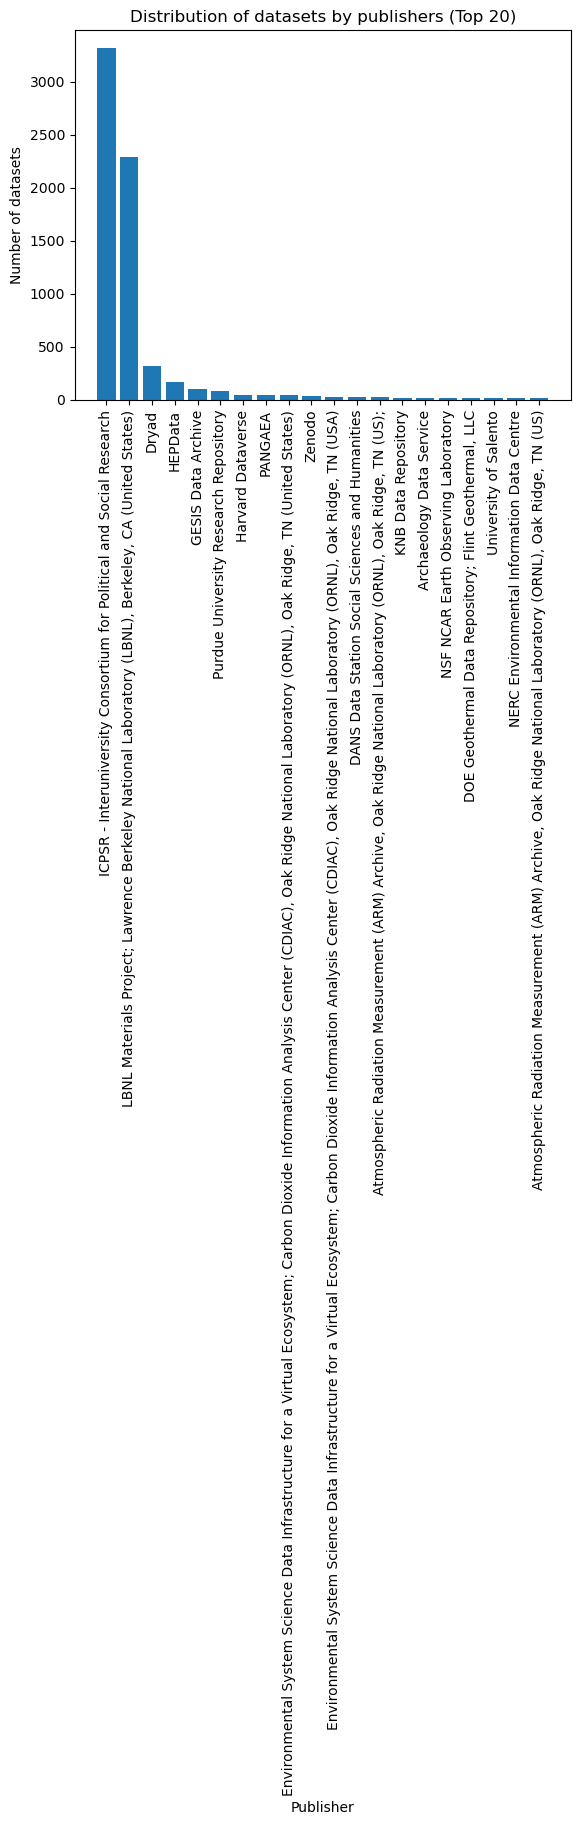

In [82]:
top_pub = pub_counts.head(20)

plt.figure()
plt.bar(top_pub.index, top_pub.values)
plt.xticks(rotation=90)
plt.xlabel('Publisher')
plt.ylabel('Number of datasets')
plt.title('Distribution of datasets by publishers (Top 20)')
plt.show()

In [83]:
(pub_counts == 1).mean()

0.5928571428571429

141 different organisations, with 60% being represented by only one example

### Banned words

In [84]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'dc_abstract', 'dc_fundingReferences',
       'dc_language', 'dc_publicationYear', 'dc_publisher', 'dc_title',
       'dc_types_resourceTypeGeneral', 'dc_url', 'doi', 'group',
       'label_vulnerable', 'source', 'flagged_words_pen', 'flagged_words_nyt',
       'flagged_words_all', 'has_flagged_word', 'num_flagged_words',
       'num_pen_words', 'num_nyt_words', 'dc_funder_first', 'abstract_len',
       'title_len', 'embeddings_allminilm', 'title_embeddings_allminilm'],
      dtype='object')

In [85]:
print(df.groupby("group").agg(
        rows=("group", "size"),
        pct_flagged=("has_flagged_word", "mean"),
        avg_abstract_len=("abstract_len", "mean")))

                      rows  pct_flagged  avg_abstract_len
group                                                    
A_drp                 2216     0.456227        154.477888
B_federal_no_flagged  2485     0.000000        129.570624
C_flagged_no_us_aff   2208     0.913496        251.547554


In [86]:
print(df.groupby("group").agg(
        rows=("group", "size"),
        pct_flagged=("has_flagged_word", "mean"),
        avg_flagged_words=("num_flagged_words", "mean"),
        avg_pen_words=("num_pen_words", "mean"),
        avg_nyt_words=("num_nyt_words", "mean")))

                      rows  pct_flagged  avg_flagged_words  avg_pen_words  \
group                                                                       
A_drp                 2216     0.456227           0.884928       0.811823   
B_federal_no_flagged  2485     0.000000           0.000000       0.000000   
C_flagged_no_us_aff   2208     0.913496           4.091033       3.678895   

                      avg_nyt_words  
group                                
A_drp                      0.513989  
B_federal_no_flagged       0.000000  
C_flagged_no_us_aff        3.017210  


Dup abstracts

In [87]:
df["dc_abstract"].value_counts().head(10)

dc_abstract
The USACE IENCs coverage area consists of 7,260 miles across 21 rivers primarily located in the Central United States. IENCs apply to inland waterways that are maintained for navigation by USACE for shallow-draft vessels (e.g., maintained at a depth of 9-14 feet, dependent upon the waterway project authorization). Generally, IENCs are produced for those commercially navigable waterways which the National Oceanic and Atmospheric Administration (NOAA) does not produce Electronic Navigational Charts (ENCs). However, Special Purpose IENCs may be produced in agreement with NOAA. IENC POC: IENC_POC@usace.army.mil                                                                                                                                                                                                                                                                                                                                                                                      

In [88]:
df["label_vulnerable"].value_counts(normalize=True)

label_vulnerable
0    0.679259
1    0.320741
Name: proportion, dtype: float64

Embeddings

In [89]:
norms = np.linalg.norm(np.vstack(df['embeddings_allminilm'].dropna().tolist()),axis=1)
print(norms.min(), norms.mean(), norms.max())

0.9999999 1.0 1.0000001


PCA

In [90]:
X = np.vstack(df['embeddings_allminilm'].tolist())
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X)
print('Explained variance:', pca.explained_variance_ratio_)

Explained variance: [0.17644887 0.06308729 0.03558695 0.02684676 0.02139461 0.01719745
 0.0161671  0.01506332 0.01394462 0.01291697]


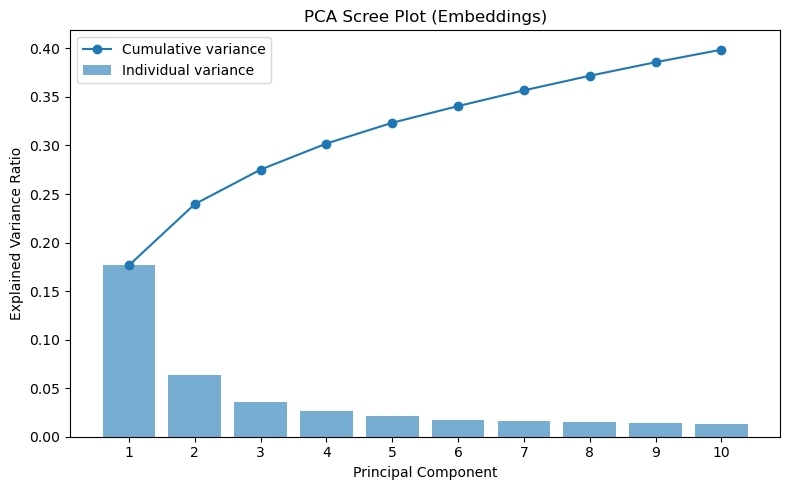

In [91]:
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(8, 5))

plt.bar(range(1, len(explained_var)+1), explained_var, alpha=0.6, label='Individual variance')
plt.plot(range(1, len(explained_var)+1), cumulative_var, marker='o', label='Cumulative variance')

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Scree Plot (Embeddings)')
plt.xticks(range(1, len(explained_var)+1))
plt.legend()

plt.tight_layout()
plt.show()

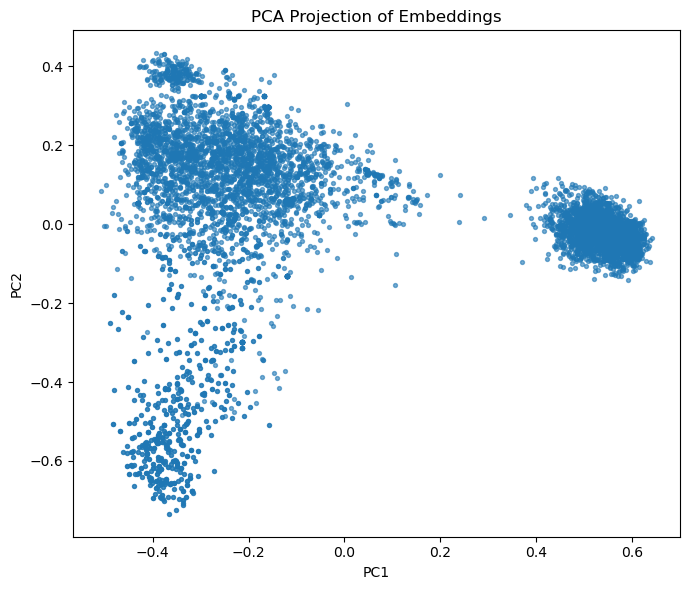

In [92]:
plt.figure(figsize=(7, 6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], s=8, alpha=0.6)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of Embeddings")

plt.tight_layout()
plt.show()

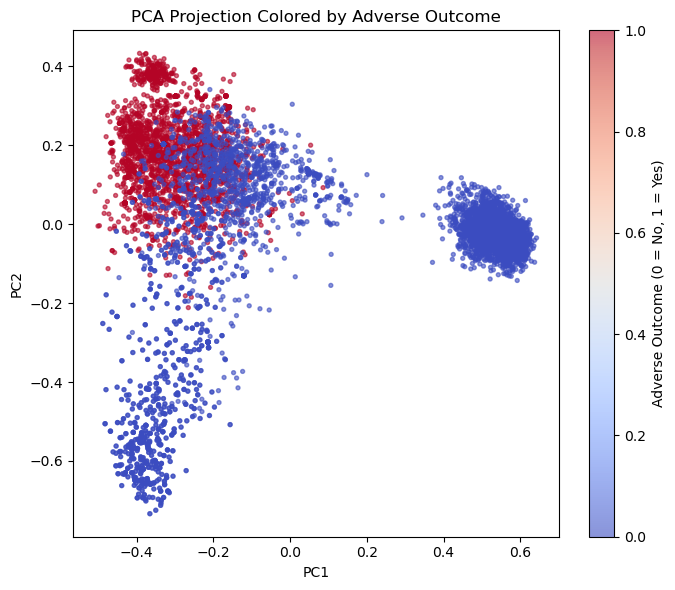

In [93]:
plt.figure(figsize=(7, 6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['label_vulnerable'], cmap='coolwarm', s=8, alpha=0.6)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection Colored by Adverse Outcome')

plt.colorbar(label='Adverse Outcome (0 = No, 1 = Yes)')

plt.tight_layout()
plt.show()

Title embeddings

In [94]:
X = np.vstack(df['title_embeddings_allminilm'].tolist())
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X)
print('Explained variance:', pca.explained_variance_ratio_)

Explained variance: [0.16221322 0.04705984 0.0302588  0.02679481 0.02437831 0.02070547
 0.01725201 0.01702608 0.01420966 0.01330808]


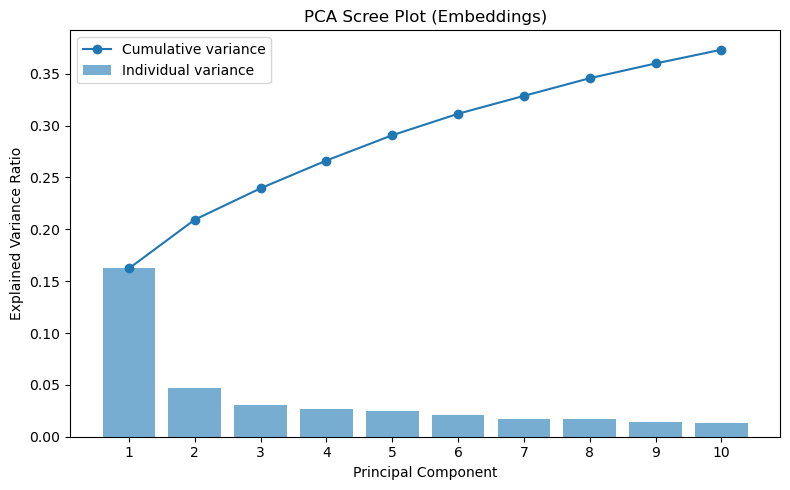

In [95]:
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(8, 5))

plt.bar(range(1, len(explained_var)+1), explained_var, alpha=0.6, label='Individual variance')
plt.plot(range(1, len(explained_var)+1), cumulative_var, marker='o', label='Cumulative variance')

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Scree Plot (Embeddings)')
plt.xticks(range(1, len(explained_var)+1))
plt.legend()

plt.tight_layout()
plt.show()

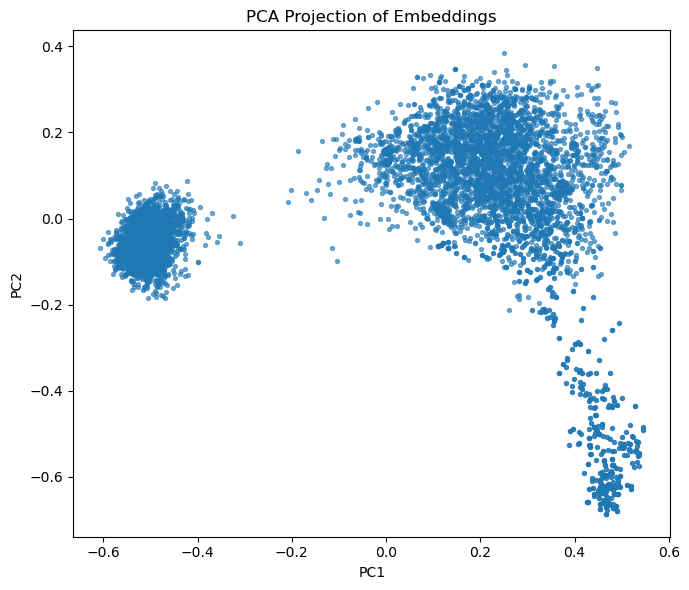

In [96]:
plt.figure(figsize=(7, 6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], s=8, alpha=0.6)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of Embeddings")

plt.tight_layout()
plt.show()

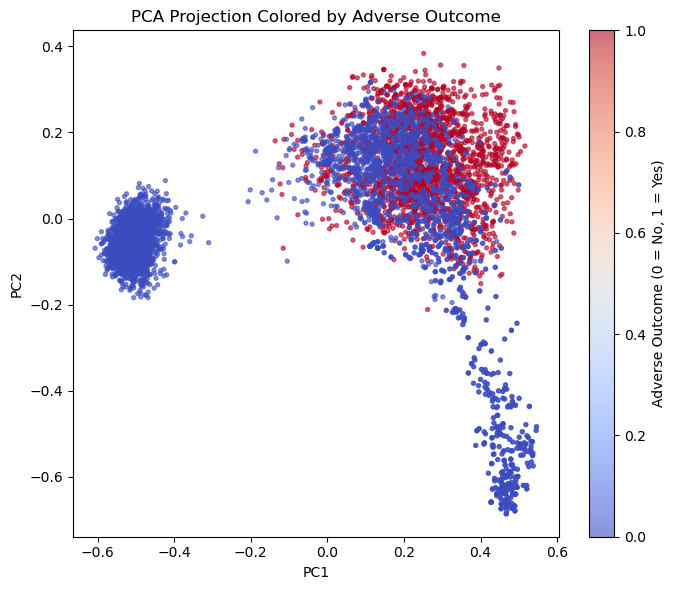

In [97]:
plt.figure(figsize=(7, 6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['label_vulnerable'], cmap='coolwarm', s=8, alpha=0.6)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection Colored by Adverse Outcome')

plt.colorbar(label='Adverse Outcome (0 = No, 1 = Yes)')

plt.tight_layout()
plt.show()

t-sne

In [98]:
df_plot = df.sample(1000, random_state=42)
X = np.vstack(df_plot['embeddings_allminilm'].tolist())

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')

X_tsne = tsne.fit_transform(X)
df_plot['tsne_x'] = X_tsne[:, 0]
df_plot['tsne_y'] = X_tsne[:, 1]

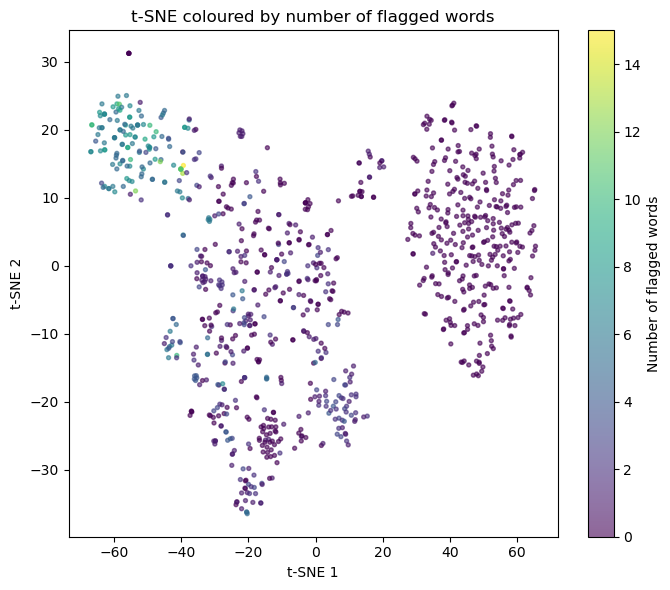

In [99]:
plt.figure(figsize=(7, 6))

scatter = plt.scatter(
    df_plot['tsne_x'],
    df_plot['tsne_y'],
    c=df_plot['num_flagged_words'],
    cmap='viridis',
    s=8,
    alpha=0.6
)

plt.title('t-SNE coloured by number of flagged words')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')

cbar = plt.colorbar(scatter)
cbar.set_label('Number of flagged words')

plt.tight_layout()
plt.show()

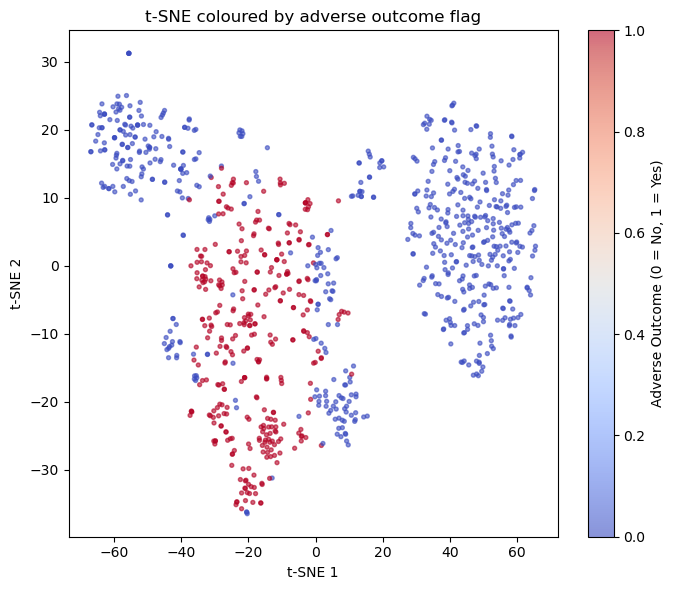

In [100]:
# Plot
plt.figure(figsize=(7, 6))

scatter = plt.scatter(
    df_plot['tsne_x'],
    df_plot['tsne_y'],
    c=df_plot['label_vulnerable'],
    cmap='coolwarm',   # binary-friendly colormap
    s=8,
    alpha=0.6
)

plt.title('t-SNE coloured by adverse outcome flag')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')

cbar = plt.colorbar(scatter)
cbar.set_label('Adverse Outcome (0 = No, 1 = Yes)')

plt.tight_layout()
plt.show()

Title embed

In [101]:
df_plot = df.sample(1000, random_state=42)
X = np.vstack(df_plot['title_embeddings_allminilm'].tolist())

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')

X_tsne = tsne.fit_transform(X)
df_plot['tsne_x'] = X_tsne[:, 0]
df_plot['tsne_y'] = X_tsne[:, 1]

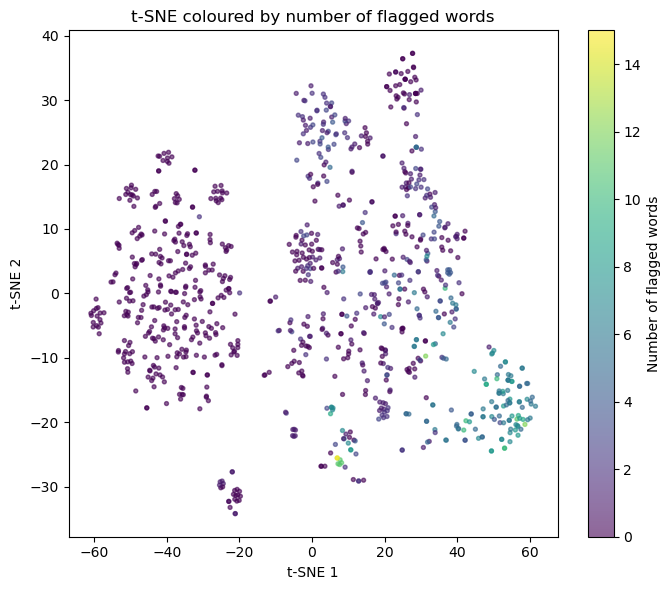

In [102]:
plt.figure(figsize=(7, 6))

scatter = plt.scatter(
    df_plot['tsne_x'],
    df_plot['tsne_y'],
    c=df_plot['num_flagged_words'],
    cmap='viridis',
    s=8,
    alpha=0.6
)

plt.title('t-SNE coloured by number of flagged words')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')

cbar = plt.colorbar(scatter)
cbar.set_label('Number of flagged words')

plt.tight_layout()
plt.show()

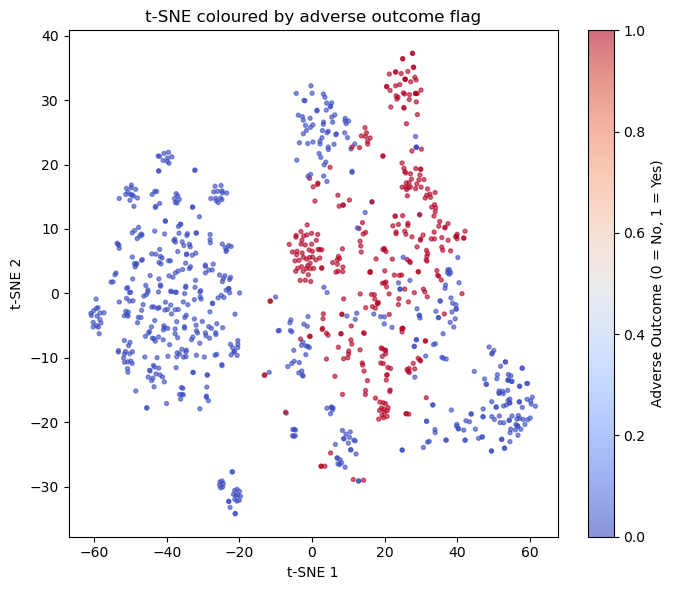

In [103]:
# Plot
plt.figure(figsize=(7, 6))

scatter = plt.scatter(
    df_plot['tsne_x'],
    df_plot['tsne_y'],
    c=df_plot['label_vulnerable'],
    cmap='coolwarm',   # binary-friendly colormap
    s=8,
    alpha=0.6
)

plt.title('t-SNE coloured by adverse outcome flag')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')

cbar = plt.colorbar(scatter)
cbar.set_label('Adverse Outcome (0 = No, 1 = Yes)')

plt.tight_layout()
plt.show()

In [104]:
df.to_csv('00_data/df_full.csv')